# Customer Segmentation (RFM)

Segment customers based on:

• Recency (how recently a customer purchased)
• Frequency (number of purchases)
• Monetary (total revenue)

This helps identify high-value and at-risk customers.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [13]:
orders = (
    df.groupby("Invoice", as_index=False)
      .agg(
          OrderValue=("Revenue","sum"),
          OrderDate=("InvoiceDate","min"),
          CustomerID=("Customer ID","first")
      )
)

In [14]:
snapshot_date = orders["OrderDate"].max() + pd.Timedelta(days=1)

In [15]:
rfm = (
    orders.groupby("CustomerID")
    .agg({
        "OrderDate": lambda x: (snapshot_date - x.max()).days,
        "Invoice": "nunique",
        "OrderValue": "sum"
    })
)

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [16]:
rfm["R_score"] = pd.qcut(rfm["Recency"],4,labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"),4,labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"],4,labels=[1,2,3,4])

In [17]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

In [18]:
def segment_customer(score):

    if score >= 10:
        return "VIP"

    if score >= 7:
        return "Loyal"

    if score >= 5:
        return "Potential"

    return "At Risk"


rfm["Segment"] = rfm["RFM_score"].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,165,11,372.86,1,4,2,7,Loyal
12347.0,3,2,1323.32,4,2,3,9,Loyal
12348.0,74,1,222.16,2,1,1,4,At Risk
12349.0,43,3,2671.14,3,3,4,10,VIP
12351.0,11,1,300.93,4,1,1,6,Potential


In [19]:
segment_counts = rfm["Segment"].value_counts()

segment_counts

Segment
Loyal        1335
VIP          1245
Potential     943
At Risk       789
Name: count, dtype: int64

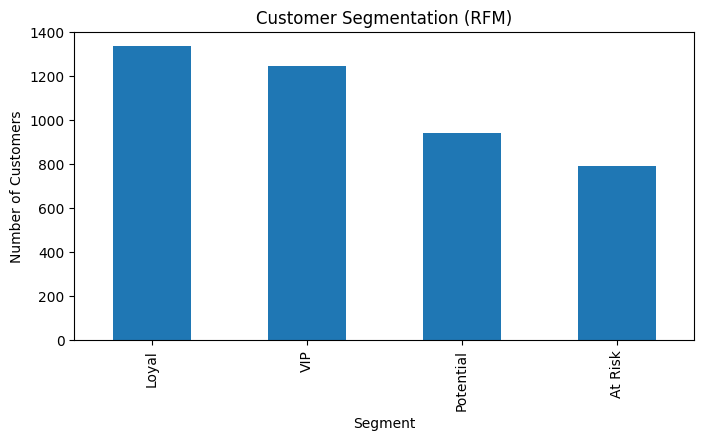

In [20]:
plt.figure(figsize=(8,4))

segment_counts.plot(kind="bar")

plt.title("Customer Segmentation (RFM)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()